In [8]:
from os.path import join as pjoin, basename
import numpy as np
import xarray as xr
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import glob

# Configure matplotlib settings
plt.rcParams['svg.fonttype'] = 'none'

In [9]:
# Configuration
save_dir = 'C:\\Users\\Eva\\Desktop\\imaging250429'
figure_dir = 'C:\\Users\\Eva\\Desktop\\Manuscript2025\\Figures\\3\\example_sessions'
n_back = 15

# All examples from all sessions

In [10]:
# Create figure directory if it doesn't exist
os.makedirs(figure_dir, exist_ok=True)

# Get all .nc files and extract session IDs
nc_files = glob.glob(pjoin(save_dir, "cellfits_halves_compare_mdl", "*.nc"))
sessions_all = []

# Extract session identifiers from filenames
for file in nc_files:
    filename = basename(file)
    if filename.startswith("sse_") and filename.endswith("hist_updated.nc"):
        # Extract session identifier
        session_id = filename.replace("sse_", "").replace("_15hist_updated.nc", "")
        sessions_all.append(session_id)

print(f"Found {len(sessions_all)} sessions to process")

# Initialize lists to store results
frac_RCp1_list = []
frac_all_list = []

# Process each session
for ss in tqdm(range(len(sessions_all)), desc="Processing sessions"):
    mouse = sessions_all[ss][:5]
    date = sessions_all[ss][6:12]
    session = sessions_all[ss][6:]
    print(f'\nChecking analysis for {mouse} on {date}')

    # Load and process data
    output_xarray = xr.open_dataset(pjoin(save_dir, 'cellfits_halves_compare_mdl', 
                                         f'sse_{sessions_all[ss]}_{n_back}hist_updated.nc'))
    
    # Calculate significance criteria
    crit_sig = output_xarray.sel(mdl_type='exp_r', half=0).p_beta_RC < 0.05
    crit_sig_half1 = output_xarray.sel(mdl_type='exp_r', half=1).p_beta_RC < 0.05
    crit_sig_half2 = output_xarray.sel(mdl_type='exp_r', half=2).p_beta_RC < 0.05

    # Extract data for different conditions
    out_pd = output_xarray.sel(half=0, mdl_type='exp_r').to_dataframe()[['beta_RC', 'tau_RC', 'norm_loglik', 'snr']]
    out_pd_half1 = output_xarray.sel(half=1, mdl_type='exp_r').to_dataframe()[['beta_RC', 'tau_RC']]
    out_pd_half2 = output_xarray.sel(half=2, mdl_type='exp_r').to_dataframe()[['beta_RC', 'tau_RC']]
    
    out_pd_null = output_xarray.sel(half=0, mdl_type='null').to_dataframe()[['beta_RC', 'tau_RC']]
    out_pd_half1_null = output_xarray.sel(half=1, mdl_type='null').to_dataframe()[['beta_RC', 'tau_RC']]
    out_pd_half2_null = output_xarray.sel(half=2, mdl_type='null').to_dataframe()[['beta_RC', 'tau_RC']]    
    
    # Add significance criteria to output
    out_pd['crit_sig'] = crit_sig
    out_pd['crit_sig_half1'] = crit_sig_half1
    out_pd['crit_sig_half2'] = crit_sig_half2
    
    # Filter significant results
    out_pd_sig = out_pd.loc[(out_pd['crit_sig'] == True) & 
                           (out_pd['tau_RC'] < 99.9) & 
                           (out_pd['tau_RC'] >= 0.11), ['tau_RC']]

    # Additional filtering criteria
    filter_criteria = ((out_pd['crit_sig_half1'] == True) & 
                      (out_pd['crit_sig_half2'] == True) & 
                      (out_pd['tau_RC'] < 99.9) & 
                      (out_pd['tau_RC'] >= 0.11))
    
    out_pd2 = out_pd.loc[filter_criteria, 'tau_RC']
    
    half_criteria = ((out_pd['crit_sig_half1'] == True) & 
                     (out_pd['crit_sig_half2'] == True) &
                     (out_pd_half1['tau_RC'] < 99.9) & 
                     (out_pd_half2['tau_RC'] < 99.9) &
                     (out_pd_half1['tau_RC'] > 0.11) & 
                     (out_pd_half2['tau_RC'] > 0.11))
    
    out_pd2_half1 = out_pd_half1.loc[half_criteria, 'tau_RC']
    out_pd2_half2 = out_pd_half2.loc[half_criteria, 'tau_RC']
    out_pd2_half1_beta = out_pd_half1.loc[half_criteria, 'beta_RC']
    out_pd2_half2_beta = out_pd_half2.loc[half_criteria, 'beta_RC']
    
    # Calculate fractions
    frac_all = len(out_pd2) / len(out_pd)
    print(f'All_crit = {frac_all:.3f} ({len(out_pd2)}/{len(out_pd)})')
    frac_all_list.append(frac_all)

    # Skip plotting if no significant cells found
    if len(out_pd2) == 0:
        print(f"No significant cells found for session {sessions_all[ss]}, skipping plots")
        continue

    # Create visualization plots
    # Plot 1: Tau comparison
    fig1, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(out_pd2_half1, out_pd2_half2, s=20, alpha=0.4, color='k', edgecolors="k")
    ax.plot([0, 90], [0, 90], color='k')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_xlim([0.1, 110])
    ax.set_ylim([0.1, 110])
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r'$ \tau$ (1st half of a session)', fontsize=15)
    ax.set_ylabel(r'$ \tau$ (2nd half of a session)', fontsize=15)

    res = stats.spearmanr(out_pd2_half1, out_pd2_half2)
    plt.text(1, 50, f'r={res[0]:.3f}, p={res[1]:.3f}', fontsize=15)
    plt.title(sessions_all[ss], fontsize=20)
    
    # Save Tau comparison plot
    fig1.savefig(pjoin(figure_dir, f'{sessions_all[ss]}_tau_comparison.svg'), 
                bbox_inches='tight', dpi=300)
    fig1.savefig(pjoin(figure_dir, f'{sessions_all[ss]}_tau_comparison.png'), 
                bbox_inches='tight', dpi=300)
    plt.close(fig1)  # Close to free memory

    # Plot 2: Beta comparison
    fig2, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(out_pd2_half1_beta, out_pd2_half2_beta, color='k', alpha=0.4, s=25, label='by ss1&ss2')
    ax.plot([-.5, .5], [-.5, .5], ls="--", c="k", alpha=0.5)

    ax.spines['left'].set_position('center')
    ax.spines['bottom'].set_position('center')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

    res = stats.pearsonr(out_pd2_half1_beta, out_pd2_half2_beta)
    plt.text(0.15, 0.45, f'r={res[0]:.3f}, p={res[1]:.3f}', fontsize=15, c='k')
    
    # Save Beta comparison plot
    fig2.savefig(pjoin(figure_dir, f'{sessions_all[ss]}_beta_comparison.svg'), 
                bbox_inches='tight', dpi=300)
    fig2.savefig(pjoin(figure_dir, f'{sessions_all[ss]}_beta_comparison.png'), 
                bbox_inches='tight', dpi=300)
    plt.close(fig2)  # Close to free memory

print("\nProcessing complete. Summary:")
print(f"Total sessions processed: {len(sessions_all)}")
print(f"Average fraction of significant cells: {np.mean(frac_all_list):.3f} ± {np.std(frac_all_list):.3f}")


Found 64 sessions to process


Processing sessions:   0%|                                                                      | 0/64 [00:00<?, ?it/s]


Checking analysis for EZ034 on 221109
All_crit = 0.170 (113/665)


Processing sessions:   2%|▉                                                             | 1/64 [00:01<01:47,  1.71s/it]


Checking analysis for EZ039 on 230414
All_crit = 0.187 (197/1053)


...


Checking analysis for MZ108 on 241122
All_crit = 0.027 (20/742)


Processing sessions:  98%|████████████████████████████████████████████████████████████ | 63/64 [01:28<00:01,  1.42s/it]


Checking analysis for MZ108 on 241126
All_crit = 0.070 (56/800)


Processing sessions: 100%|█████████████████████████████████████████████████████████████| 64/64 [01:29<00:00,  1.40s/it]


Processing complete. Summary:
Total sessions processed: 64
Average fraction of significant cells: 0.094 ± 0.054



Checking analysis for EZ055 on 240219


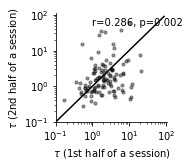

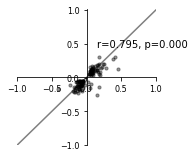

In [14]:
figure_dir = 'C:\\Users\\Eva\\Desktop\\Manuscript2025\\Figures\\2\\example_sessions\\selected'
# sessions_all = ['EZ034_221108']
# sessions_all = ['EZ050_231225']
sessions_all = ['EZ055_240219']
ss=0
mouse = sessions_all[ss][:5]
date = sessions_all[ss][6:12]
session = sessions_all[ss][6:]
print(f'\nChecking analysis for {mouse} on {date}')

# Load and process data
output_xarray = xr.open_dataset(pjoin(save_dir, 'cellfits_halves_compare_mdl', 
                                     f'sse_{sessions_all[ss]}_{n_back}hist_updated.nc'))

# Calculate significance criteria
crit_sig = output_xarray.sel(mdl_type='exp_r', half=0).p_beta_RC < 0.05
crit_sig_half1 = output_xarray.sel(mdl_type='exp_r', half=1).p_beta_RC < 0.05
crit_sig_half2 = output_xarray.sel(mdl_type='exp_r', half=2).p_beta_RC < 0.05

# Extract data for different conditions
out_pd = output_xarray.sel(half=0, mdl_type='exp_r').to_dataframe()[['beta_RC', 'tau_RC', 'norm_loglik', 'snr']]
out_pd_half1 = output_xarray.sel(half=1, mdl_type='exp_r').to_dataframe()[['beta_RC', 'tau_RC']]
out_pd_half2 = output_xarray.sel(half=2, mdl_type='exp_r').to_dataframe()[['beta_RC', 'tau_RC']]

out_pd_null = output_xarray.sel(half=0, mdl_type='null').to_dataframe()[['beta_RC', 'tau_RC']]
out_pd_half1_null = output_xarray.sel(half=1, mdl_type='null').to_dataframe()[['beta_RC', 'tau_RC']]
out_pd_half2_null = output_xarray.sel(half=2, mdl_type='null').to_dataframe()[['beta_RC', 'tau_RC']]    

# Add significance criteria to output
out_pd['crit_sig'] = crit_sig
out_pd['crit_sig_half1'] = crit_sig_half1
out_pd['crit_sig_half2'] = crit_sig_half2

# Filter significant results
out_pd_sig = out_pd.loc[(out_pd['crit_sig'] == True) & 
                       (out_pd['tau_RC'] < 99.9) & 
                       (out_pd['tau_RC'] >= 0.11), ['tau_RC']]

# Additional filtering criteria
filter_criteria = ((out_pd['crit_sig_half1'] == True) & 
                  (out_pd['crit_sig_half2'] == True) & 
                  (out_pd['tau_RC'] < 99.9) & 
                  (out_pd['tau_RC'] >= 0.11))

out_pd2 = out_pd.loc[filter_criteria, 'tau_RC']

half_criteria = ((out_pd['crit_sig_half1'] == True) & 
                 (out_pd['crit_sig_half2'] == True) &
                 (out_pd_half1['tau_RC'] < 99.9) & 
                 (out_pd_half2['tau_RC'] < 99.9) &
                 (out_pd_half1['tau_RC'] > 0.11) & 
                 (out_pd_half2['tau_RC'] > 0.11))

out_pd2_half1 = out_pd_half1.loc[half_criteria, 'tau_RC']
out_pd2_half2 = out_pd_half2.loc[half_criteria, 'tau_RC']
out_pd2_half1_beta = out_pd_half1.loc[half_criteria, 'beta_RC']
out_pd2_half2_beta = out_pd_half2.loc[half_criteria, 'beta_RC']


# Create visualization plots
# Plot 1: Tau comparison
fig1, ax = plt.subplots(figsize=(2, 2))
ax.scatter(out_pd2_half1, out_pd2_half2, s=10, alpha=0.4, color='k', edgecolors="k")
ax.plot([0, 90], [0, 90], color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim([0.1, 110])
ax.set_ylim([0.1, 110])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r'$ \tau$ (1st half of a session)', fontsize=10)
ax.set_ylabel(r'$ \tau$ (2nd half of a session)', fontsize=10)

res = stats.spearmanr(out_pd2_half1, out_pd2_half2)
plt.text(1, 50, f'r={res[0]:.3f}, p={res[1]:.3f}', fontsize=10)
# plt.title(sessions_all[ss], fontsize=20)

# Save Tau comparison plot
fig1.savefig(pjoin(figure_dir, f'{sessions_all[ss]}_tau_comparison.svg'), 
            bbox_inches='tight', dpi=300)
fig1.savefig(pjoin(figure_dir, f'{sessions_all[ss]}_tau_comparison.png'), 
            bbox_inches='tight', dpi=300)
#     plt.close(fig1)  # Close to free memory

# Plot 2: Beta comparison
fig2, ax = plt.subplots(figsize=(2.5, 2.5))
ax.scatter(out_pd2_half1_beta, out_pd2_half2_beta, color='k', alpha=0.4, s=10, label='by ss1&ss2')
ax.plot([-1, 1], [-1, 1], c="k", alpha=0.5)
ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# Set the limits to -0.8, 0.8 for both axes
ax.set_xlim(-1, 1.01)
ax.set_ylim(-1, 1.01)

# Set ticks to be 0.2 apart
ax.set_xticks(np.arange(-1, 1.01, 0.5))
ax.set_yticks(np.arange(-1, 1.01, 0.5))

# Make tick labels smaller
ax.tick_params(axis='both', which='major', labelsize=8)

res = stats.spearmanr(out_pd2_half1_beta, out_pd2_half2_beta)
plt.text(0.15, 0.45, f'r={res[0]:.3f}, p={res[1]:.3f}', fontsize=10, c='k')
# Save Beta comparison plot
fig2.savefig(pjoin(figure_dir, f'{sessions_all[ss]}_beta_comparison.svg'), 
            bbox_inches='tight', dpi=300)
fig2.savefig(pjoin(figure_dir, f'{sessions_all[ss]}_beta_comparison.png'), 
            bbox_inches='tight', dpi=300)
#     plt.close(fig2)


Checking analysis for EZ055 on 240219


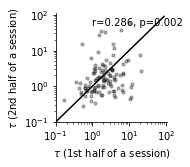

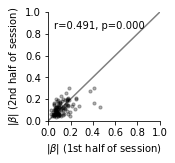

In [17]:
figure_dir = 'C:\\Users\\Eva\\Desktop\\Manuscript2025\\Figures\\2\\example_sessions\\selected'
# sessions_all = ['EZ034_221108']
# sessions_all = ['EZ050_231225']
sessions_all = ['EZ055_240219']
ss=0
mouse = sessions_all[ss][:5]
date = sessions_all[ss][6:12]
session = sessions_all[ss][6:]
print(f'\nChecking analysis for {mouse} on {date}')

# Load and process data
output_xarray = xr.open_dataset(pjoin(save_dir, 'cellfits_halves_compare_mdl', 
                                     f'sse_{sessions_all[ss]}_{n_back}hist_updated.nc'))

# Calculate significance criteria
crit_sig = output_xarray.sel(mdl_type='exp_r', half=0).p_beta_RC < 0.05
crit_sig_half1 = output_xarray.sel(mdl_type='exp_r', half=1).p_beta_RC < 0.05
crit_sig_half2 = output_xarray.sel(mdl_type='exp_r', half=2).p_beta_RC < 0.05

# Extract data for different conditions
out_pd = output_xarray.sel(half=0, mdl_type='exp_r').to_dataframe()[['beta_RC', 'tau_RC', 'norm_loglik', 'snr']]
out_pd_half1 = output_xarray.sel(half=1, mdl_type='exp_r').to_dataframe()[['beta_RC', 'tau_RC']]
out_pd_half2 = output_xarray.sel(half=2, mdl_type='exp_r').to_dataframe()[['beta_RC', 'tau_RC']]

out_pd_null = output_xarray.sel(half=0, mdl_type='null').to_dataframe()[['beta_RC', 'tau_RC']]
out_pd_half1_null = output_xarray.sel(half=1, mdl_type='null').to_dataframe()[['beta_RC', 'tau_RC']]
out_pd_half2_null = output_xarray.sel(half=2, mdl_type='null').to_dataframe()[['beta_RC', 'tau_RC']]    

# Add significance criteria to output
out_pd['crit_sig'] = crit_sig
out_pd['crit_sig_half1'] = crit_sig_half1
out_pd['crit_sig_half2'] = crit_sig_half2

# Filter significant results
out_pd_sig = out_pd.loc[(out_pd['crit_sig'] == True) & 
                       (out_pd['tau_RC'] < 99.9) & 
                       (out_pd['tau_RC'] >= 0.11), ['tau_RC']]

# Additional filtering criteria
filter_criteria = ((out_pd['crit_sig_half1'] == True) & 
                  (out_pd['crit_sig_half2'] == True) & 
                  (out_pd['tau_RC'] < 99.9) & 
                  (out_pd['tau_RC'] >= 0.11))

out_pd2 = out_pd.loc[filter_criteria, 'tau_RC']

half_criteria = ((out_pd['crit_sig_half1'] == True) & 
                 (out_pd['crit_sig_half2'] == True) &
                 (out_pd_half1['tau_RC'] < 99.9) & 
                 (out_pd_half2['tau_RC'] < 99.9) &
                 (out_pd_half1['tau_RC'] > 0.11) & 
                 (out_pd_half2['tau_RC'] > 0.11))

out_pd2_half1 = out_pd_half1.loc[half_criteria, 'tau_RC']
out_pd2_half2 = out_pd_half2.loc[half_criteria, 'tau_RC']
out_pd2_half1_beta = out_pd_half1.loc[half_criteria, 'beta_RC']
out_pd2_half2_beta = out_pd_half2.loc[half_criteria, 'beta_RC']


# Create visualization plots
# Plot 1: Tau comparison
fig1, ax = plt.subplots(figsize=(2, 2))
ax.scatter(out_pd2_half1, out_pd2_half2, s=10, alpha=0.3, color='k', edgecolors="k")
ax.plot([0, 90], [0, 90], color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim([0.1, 110])
ax.set_ylim([0.1, 110])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r'$ \tau$ (1st half of a session)', fontsize=10)
ax.set_ylabel(r'$ \tau$ (2nd half of a session)', fontsize=10)

res = stats.spearmanr(out_pd2_half1, out_pd2_half2)
plt.text(1, 50, f'r={res[0]:.3f}, p={res[1]:.3f}', fontsize=10)
# plt.title(sessions_all[ss], fontsize=20)

# Save Tau comparison plot
fig1.savefig(pjoin(figure_dir, f'{sessions_all[ss]}_tau_comparison.svg'), 
            bbox_inches='tight', dpi=300)
fig1.savefig(pjoin(figure_dir, f'{sessions_all[ss]}_tau_comparison.png'), 
            bbox_inches='tight', dpi=300)
#     plt.close(fig1)  # Close to free memory

# Plot 2: Beta comparison with absolute values
# Convert beta values to absolute values
abs_beta_half1 = np.abs(out_pd2_half1_beta)
abs_beta_half2 = np.abs(out_pd2_half2_beta)

fig2, ax = plt.subplots(figsize=(2, 2))
ax.scatter(abs_beta_half1, abs_beta_half2, color='k', alpha=0.3, s=10, label='by ss1&ss2')
ax.plot([0, 1], [0, 1], c="k", alpha=0.5)  # Identity line from (0,0) to (1,1)

# Set up the axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Set the limits to 0, 1 for both axes
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
# Set specific ticks at 0, 0.2, 0.4, 0.6, 0.8, 1
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Make tick labels smaller
ax.tick_params(axis='both', which='major', labelsize=10)

# Add axis labels
ax.set_xlabel(r'$|\beta|$ (1st half of session)', fontsize=10)
ax.set_ylabel(r'$|\beta|$ (2nd half of session)', fontsize=10)

# Calculate correlation on the absolute values
res = stats.spearmanr(abs_beta_half1, abs_beta_half2)
plt.text(0.05, 0.85, f'r={res[0]:.3f}, p={res[1]:.3f}', fontsize=10, c='k')

# Save Beta comparison plot
fig2.savefig(pjoin(figure_dir, f'{sessions_all[ss]}_abs_beta_comparison.svg'), 
            bbox_inches='tight', dpi=300)
fig2.savefig(pjoin(figure_dir, f'{sessions_all[ss]}_abs_beta_comparison.png'), 
            bbox_inches='tight', dpi=300)
#     plt.close(fig2)